<a href="https://colab.research.google.com/github/Vronska-Anhelina/-Prediction-and-Clustering-Models/blob/main/Credit_Scoring_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical task. Logistic regression

Client applies for a new credit card. The task of the model used by the bank is to assess the client’s **creditworthiness**, i.e., the probability of a positive credit history, and decide whether to approve or reject the credit card application.

**Data description:**

* **card**: **target variable**, whether the application was approved ("yes" or "no");
* **reports**: number of negative credit histories;
* **age**: client’s age;
* **income**: annual income (divided by 10,000);
* **share**: ratio of monthly credit card expenses to annual income;
* **expenditure**: average monthly credit card expenses;
* **owner**: "yes" if the client owns housing, "no" if renting;
* **selfempl**: "yes" if self-employed, "no" otherwise;
* **dependents**: number of dependents supported by the client plus one;
* **months**: number of months the client has lived at the current address;
* **majorcards**: number of credit cards the client has;
* **active**: number of active credit accounts.

**Work plan:**

1. Load the dataset from [Google Drive](https://drive.google.com/file/d/1X5SzL0n2i3YKyylIaIMNr-sm8H1Df3M4/view?usp=drive_link).
2. Check the data for missing values. If rows with missing values exist, remove them from the dataset.
3. Convert text fields (**card, owner, selfempl**) to numeric according to the rule: "yes" → 1, "no" → 0.
4. Prepare the data for model building.
5. Split the data into training and test sets.
6. Standardize the data to equalize scales.
7. Train a logistic regression model with default hyperparameters. Modify defaults if necessary.
8. Output the model’s weight coefficients. Build a two-color bar chart as shown in the theory example. Which variables positively influence credit card approval, and which negatively? Draw conclusions about the importance of variables in the model.


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
path = "/content/drive/MyDrive/mate/credit_card_data.csv"
df = pd.read_csv(path)
df.head()

Mounted at /content/drive


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
df = df.replace({'yes': 1, 'no': 0})
X = df.drop(["card"], axis=1)
y = df["card"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=2026)
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

/tmp/ipykernel_935/870452902.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes': 1, 'no': 0})


LogisticRegression()

In [ ]:
coef=model.coef_[0]
feature_means=X.columns
importance_df=pd.DataFrame({
    "Feature":feature_means,
    "Importance":coef
}).sort_values(by="Importance")
print(importance_df)

        Feature  Importance
0       reports   -1.996353
7    dependents   -0.257485
8        months   -0.134422
6       selfemp   -0.105738
1           age    0.091688
9    majorcards    0.114916
5         owner    0.194854
2        income    0.251199
10       active    0.598066
4   expenditure    4.798281
3         share    5.490862


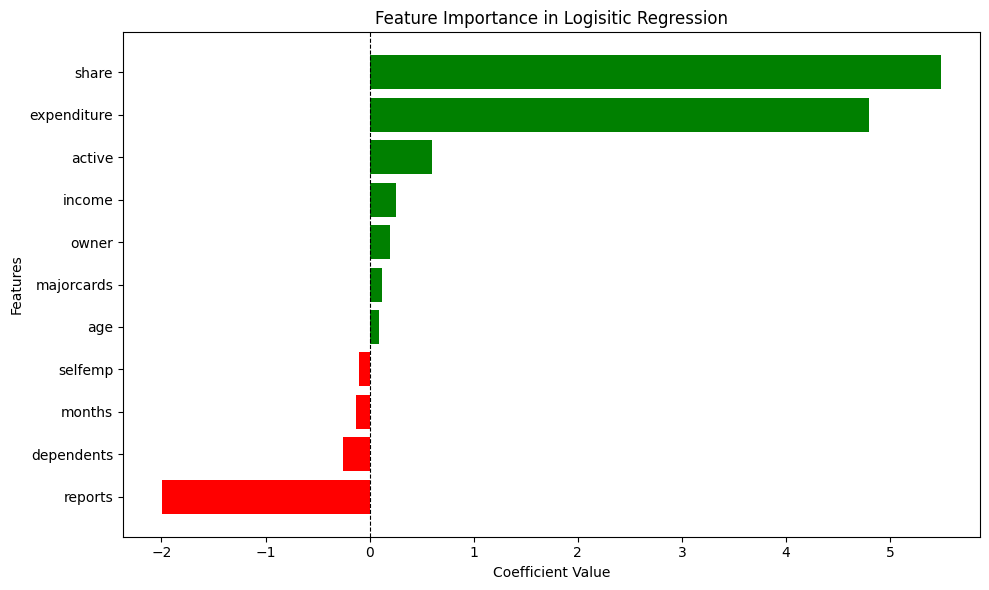

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
colors=["green" if val>0 else "red" for val in importance_df["Importance"]]
plt.barh(importance_df["Feature"], importance_df["Importance"],color=colors)
plt.axvline(0,color="black",linewidth=0.8,linestyle="--")
plt.title("Feature Importance in Logisitic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

The share (share of expenses to income) and expenditure (expenses) attributes have the largest positive coefficients. This means that with the increase of these indicators, the probability that the value of the target variable (card) will be "yes" increases significantly.

The reports attribute has the most pronounced negative coefficient. This is logical: the more negative reports, the lower the probability of receiving a card.

Such attributes as age (age), majorcards and owner have coefficients close to zero, which indicates their minimal impact on the final solution of the model compared to other indicators.

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test_scaled)
print(f"Accuracy scores:{accuracy_score(y_test,y_pred)}")

Accuracy scores:0.9454545454545454


In [ ]:
df["card"].value_counts(normalize=True)

,proportion
card,
1,0.775588
0,0.224412


We see an uneven distribution, with class 1 accounting for 77% and class 2 accounting for 22%. Therefore, it is not appropriate to use accuracy scores in this case.

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score

print(f"Precision_score:{precision_score(y_test,y_pred)}")
print(f"Recall score:{recall_score(y_test,y_pred)}")
print(f"F-1 score:{f1_score(y_test,y_pred)}")

Precision_score:0.951417004048583
Recall score:0.975103734439834
F-1 score:0.9631147540983607


If the model predicts the creditworthiness of a client, then these results can be trusted by 95%, which is an almost accurate result. The model is able to find 97% of clients who are close to this value. Overall, the preliminary accuracy of the results is 96%. In all three cases, the model shows almost accurate results - 95% and above, which indicates good model performance.

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
tn=cm[0,0]
fn=cm[1,0]
fp=cm[0,1]
specificity=tn/(tn+fp)
print(f"Confusion matrix:{confusion_matrix(y_test,y_pred)}")
print(f"Specificity:{specificity}")

Confusion matrix:[[ 89   0]
 [  9 232]]
Specificity:1.0


The model predicts class 0 in 100% of cases.

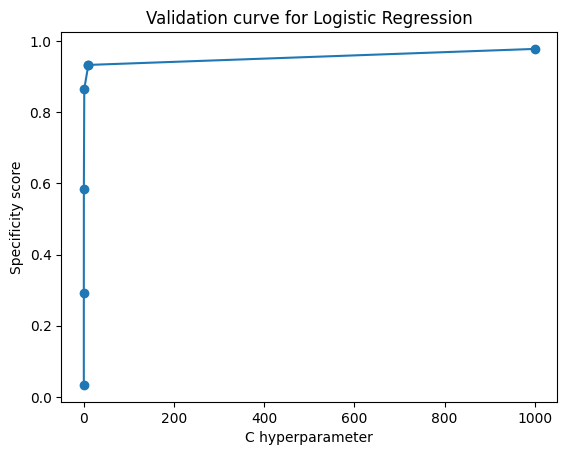

In [ ]:
possible_C = [0.001, 0.01, 0.1, 1, 10, 10, 1000]
specificity_scores = []
for C in possible_C:
  model = LogisticRegression(C=C)
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  cm = confusion_matrix(y_test, y_pred)
  tn = cm[0, 0]
  tp = cm[1, 1]
  fn = cm[1, 0]
  fp = cm[0, 1]
  specificity_scores.append(tn / (tn + fp))
plt.plot(possible_C, specificity_scores, marker="o")
plt.xlabel("C hyperparameter")
plt.ylabel("Specificity score")
plt.title("Validation curve for Logistic Regression")
plt.show()

The best model turned out to be the one with C = 1000. Let's build this model and evaluate its performance using all relevant metrics.

In [ ]:
best_model = LogisticRegression(C=1000)
best_model.fit(X_train_scaled, y_train)
best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
fp = cm[0, 1]
specificity = tn / (tn + fp)
print(confusion_matrix(y_test, y_pred))
print()
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Specificity:", specificity)

[[ 87   2]
 [  7 234]]

Precision: 0.9915254237288136
Recall: 0.970954356846473
F1 score: 0.9811320754716981
Specificity: 0.9775280898876404


After introducing the hyperparameter c=1000, the results clearly improved and became more accurate: The proportion of predictions of positive classes is correct - 99%, Completeness 97% and the average between these values: 98%. Also, the specificity is 97%. All these results indicate a good performance of the model, because the results are quite high, and therefore the predictions are almost accurate.